In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from tqdm import tqdm
import os

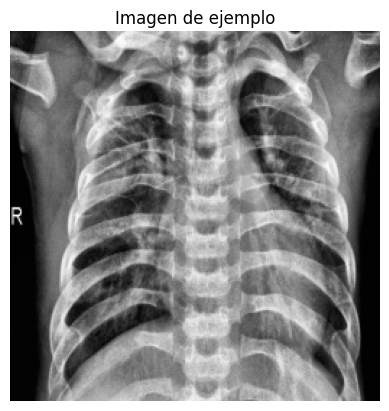

In [2]:
example_path = "../data/Train/PNEUMONIA/person1001_bacteria_2932_92394105.jpg"
img = cv2.imread(example_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Imagen de ejemplo")
plt.axis("off")
plt.show()


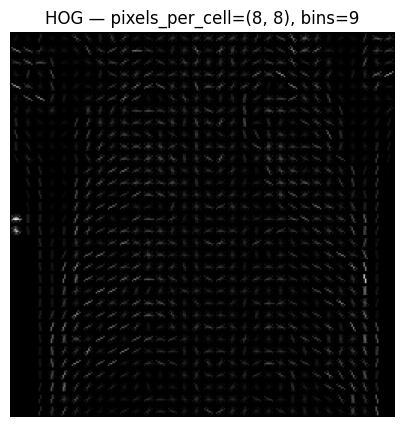

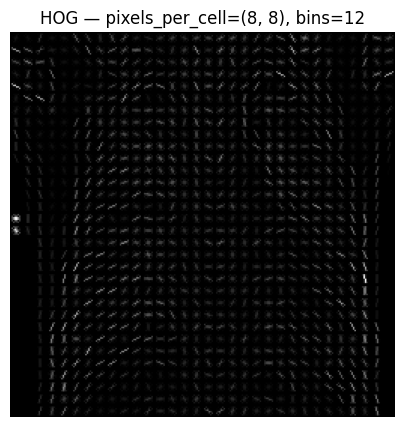

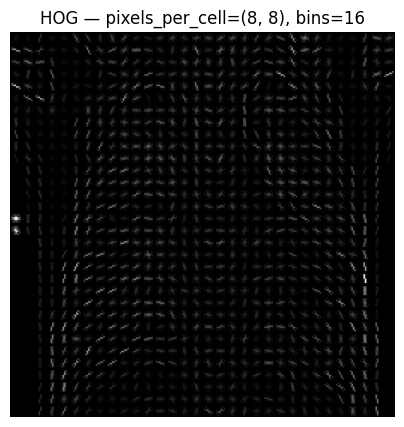

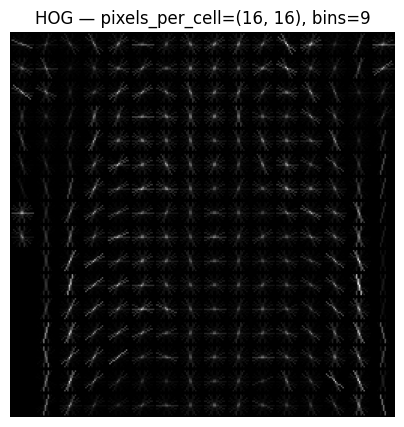

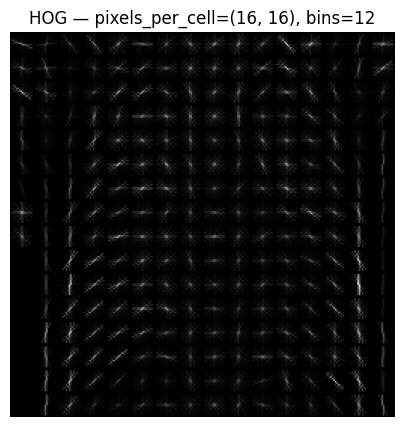

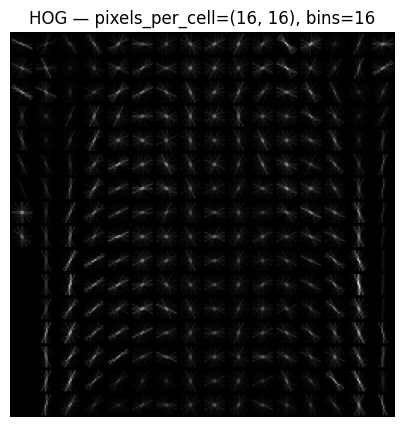

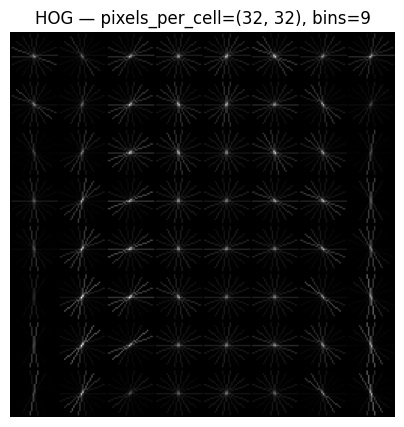

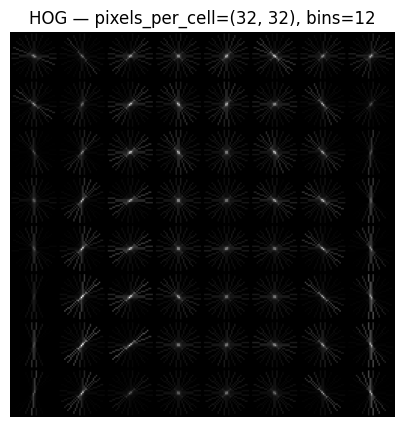

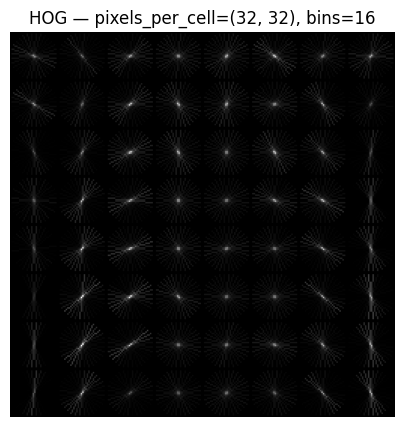

In [3]:
def descriptor_hog(img, orientations=9, pixels_per_cell=(16,16)):
    feat, hog_img = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=True
    )
    return feat, hog_img

pixel_options = [(8,8), (16,16), (32,32)]
bin_options = [9, 12, 16]

for pix in pixel_options:
    for bins in bin_options:
        _, hog_img = descriptor_hog(img, orientations=bins, pixels_per_cell=pix)
        plt.figure(figsize=(5,5))
        plt.imshow(hog_img, cmap="gray")
        plt.title(f"HOG — pixels_per_cell={pix}, bins={bins}")
        plt.axis("off")
        plt.show()


In [4]:
def descriptor_hu(img):
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    return hu

hu = descriptor_hu(img)
for i, v in enumerate(hu):
    print(f"Hu[{i}] = {v}")


Hu[0] = 0.0012771020681901827
Hu[1] = 4.052055487718773e-08
Hu[2] = 3.745547392919188e-11
Hu[3] = 1.8312980341240394e-12
Hu[4] = 1.0280887448000521e-23
Hu[5] = 4.934313361647e-17
Hu[6] = -1.1150674427981367e-23


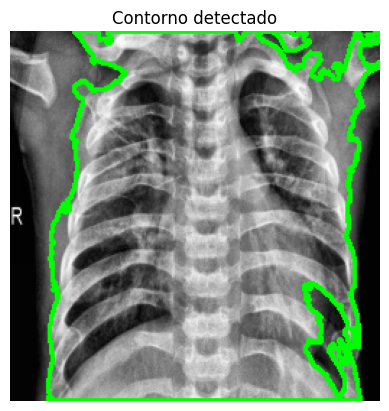

In [5]:
def segmentar(img):
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def descriptor_contorno(img):
    th = segmentar(img)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return np.array([0,0,0,0])

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, True)
    circularity = (4 * np.pi * area / (perim**2)) if perim != 0 else 0

    if len(cnt) >= 5:
        (x,y),(MA,ma),angle = cv2.fitEllipse(cnt)
        eccentricity = np.sqrt(1 - (MA/ma)**2)
    else:
        eccentricity = 0

    return np.array([area, perim, circularity, eccentricity])

th = segmentar(img)
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_color, [cnt], -1, (0,255,0), 2)

plt.imshow(img_color[...,::-1])
plt.title("Contorno detectado")
plt.axis("off")
plt.show()



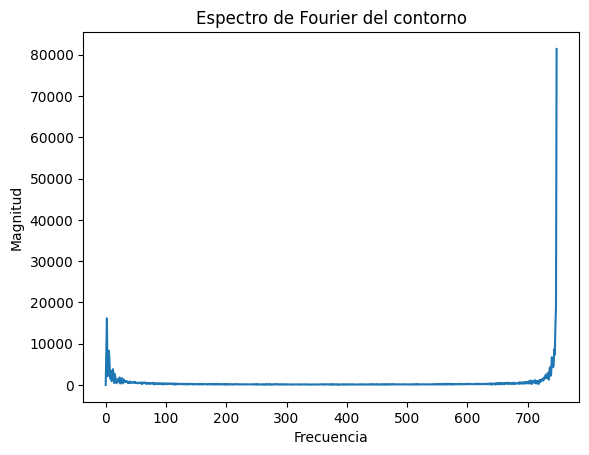

In [6]:
def descriptor_fourier(img, n_coeffs=20):
    # 1. Segmentación por Otsu
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Si no hay contornos → vector vacío
    if len(contours) == 0:
        return np.zeros(2*n_coeffs)

    # 2. Elegir contorno más grande
    cnt = max(contours, key=cv2.contourArea)
    c = np.squeeze(cnt)

    # Validar forma (N,2)
    if c.ndim != 2 or c.shape[0] < 10:
        return np.zeros(2*n_coeffs)

    # 3. Serie compleja
    complex_contour = c[:,0] + 1j * c[:,1]

    # Remover componente DC → invariancia a traslación
    complex_contour = complex_contour - complex_contour.mean()

    # 4. Transformada
    fourier = np.fft.fft(complex_contour)

    # 5. Normalización por el primer coef. no nulo → invariancia de escala
    ref = np.abs(fourier[1])
    if ref == 0:
        ref = 1
    fourier_norm = fourier / ref

    # 6. Tomar primeros N coeficientes
    coeffs = fourier_norm[:n_coeffs]

    # 7. Concatenar real + imaginario → feature vector final
    fsd_vec = np.concatenate([np.real(coeffs), np.imag(coeffs)])

    return fsd_vec

# Para visualizar el espectro Fourier del contorno

# 1. Segmentar
_, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("No se encontraron contornos.")
else:
    cnt = max(contours, key=cv2.contourArea)
    c = np.squeeze(cnt)

    if c.ndim == 2 and c.shape[0] >= 10:
        complex_contour = c[:,0] + 1j * c[:,1]
        complex_contour = complex_contour - complex_contour.mean()

        fourier = np.fft.fft(complex_contour)

        # Mostrar espectro
        plt.plot(np.abs(fourier))
        plt.title("Espectro de Fourier del contorno")
        plt.xlabel("Frecuencia")
        plt.ylabel("Magnitud")
        plt.show()
    else:
        print("Contorno demasiado pequeño o inválido.")




In [7]:
def extract_descriptors(img, n_fourier=20):
    hog_feat, _ = descriptor_hog(img)
    hu_feat = descriptor_hu(img)
    cnt_feat = descriptor_contorno(img)
    fourier_feat = descriptor_fourier(img, n_coeffs=n_fourier)

    return np.concatenate([hog_feat, hu_feat, cnt_feat, fourier_feat])

def process_dataset(root_dir):
    X = []
    y = []
    classes = os.listdir(root_dir)

    for label in classes:
        folder = os.path.join(root_dir, label)
        images = os.listdir(folder)

        print(f"Procesando {label} ({len(images)} imágenes)")

        for fname in tqdm(images):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            feats = extract_descriptors(img)
            X.append(feats)
            y.append(label)

    return np.array(X), np.array(y)



In [8]:
train_dir = "../data/Train"
val_dir = "../data/Val"
test_dir = "../data/Test"

X_train, y_train = process_dataset(train_dir)
X_val, y_val = process_dataset(val_dir)
X_test, y_test = process_dataset(test_dir)


Procesando PNEUMONIA (2991 imágenes)


100%|██████████| 2991/2991 [01:12<00:00, 41.40it/s]


Procesando NORMAL (1108 imágenes)


100%|██████████| 1108/1108 [00:27<00:00, 39.69it/s]


Procesando PNEUMONIA (641 imágenes)


...

100%|██████████| 237/237 [00:05<00:00, 40.06it/s]


Procesando PNEUMONIA (641 imágenes)


100%|██████████| 641/641 [00:16<00:00, 39.86it/s]


Procesando NORMAL (238 imágenes)


100%|██████████| 238/238 [00:06<00:00, 37.54it/s]


In [ ]:
np.save("X_train_2A.npy", X_train)
np.save("y_train_2A.npy", y_train)

np.save("X_val_2A.npy", X_val)
np.save("y_val_2A.npy", y_val)

np.save("X_test_2A.npy", X_test)
np.save("y_test_2A.npy", y_test)
